# A4.1 — Detecção de COVID-19 em Radiografias de Tórax: diagnóstico e augmentation com GAN

**Objetivo:** diagnosticar as falhas do sistema de triagem de um grupo anterior (1.200 raios-X: Normal 840 /
Pneumonia 240 / COVID-19 120; ResNet-18 do zero, SGD lr=0,01 fixo, 15 epochs, sem augmentation, só accuracy →
93% treino / 61% validação) e avaliar se **imagens sintéticas geradas por uma GAN condicional** aumentam a
**recall da classe COVID-19**.

- **§2** Diagnóstico: ≥5 problemas técnicos com impacto clínico, com evidência numérica.
- **§3** Reprodução do protocolo do grupo anterior (a falha acontece de fato?).
- **§4–5** GAN condicional (cDCGAN) para raio-X, diagnóstico de instabilidade e mitigação com evidência.
- **§6** Experimento controlado: classificador **com vs. sem** imagens sintéticas (3 seeds, test set isolado).
- **§7** Plano de melhoria integrado (modelo · métrica · augmentation sintética · critério de adoção clínica).

> Notebook **autossuficiente**: roda do início ao fim no Google Colab (GPU T4) sem edições. O dataset é baixado
> via `kagglehub` (público, sem credenciais); se falhar, o notebook pede o `kaggle.json`. Seeds fixas.

Referência central: Nour & Tariq (2023), *Scientific Reports* — https://www.nature.com/articles/s41598-023-37743-4

## Requisitos de execução

| Recurso | Valor |
|---|---|
| Ambiente | Google Colab, GPU **T4** (Runtime → Change runtime type → T4 GPU) |
| RAM de sistema | ~3,6 GB (processo, medido) |
| VRAM (GPU) | ~4,9 GB de pico (medido; cabe na T4 de 15 GB) |
| Disco | ~1,5 GB (COVID-19 Radiography Database, ~800 MB zip) |
| Tempo (execução completa, T4) | **~36 min** medidos: dataset ~0,5 min · baseline ~0,8 min · 4 GANs ~25 min · experimento (9 treinos) ~9 min |

> Valores medidos na execução completa em Colab T4 (impressos na última célula, § Medições). Tempo por seção fica em `TIMES`.

## 0. Setup

In [1]:
!pip -q install kagglehub

In [2]:
import os, random, time, copy, json, math, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import v2 as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True
print("device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "(CPU)")

T_START = time.time()
TIMES = {}      # tempo por seção (s)
RESULTS = {}    # tudo que vai para results.json

device: cuda Tesla T4


## 1. Dataset e reprodução do cenário 840 / 240 / 120

Fonte: Kaggle `tawsifurrahman/covid19-radiography-database` (Chowdhury et al., 2020; Rahman et al., 2021) —
PNG 299×299 em escala de cinza, pastas `Normal`, `Viral Pneumonia`, `COVID` (e `Lung_Opacity`, não usada).

Para reproduzir o cenário do grupo anterior, sorteio (seed fixa) **exatamente 840 Normal, 240 Pneumonia e
120 COVID-19**. As imagens ficam em memória como `uint8` 224×224 (~60 MB).

In [3]:
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ROOT = Path("/content") if IN_COLAB else Path(".")
DATA_DIR, FIG_DIR = ROOT / "data", ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if IN_COLAB else 0
KAGGLE_ID = "tawsifurrahman/covid19-radiography-database"


def find_root(base):
    base = Path(base)
    for cand in [base, *base.glob("*"), *base.glob("*/*")]:
        if (cand / "COVID" / "images").is_dir():
            return cand
    return None


t0 = time.time()
ds_root = find_root(DATA_DIR)
if ds_root is None:
    try:
        import kagglehub
        ds_root = find_root(kagglehub.dataset_download(KAGGLE_ID))
    except Exception as e:
        print("kagglehub falhou:", e, "-> Kaggle API com kaggle.json")
        if IN_COLAB and not Path("~/.kaggle/kaggle.json").expanduser().exists():
            from google.colab import files
            print("Faça upload do kaggle.json (Kaggle -> Settings -> Create New Token):")
            files.upload()
            os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
            os.replace("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
            os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
        os.system(f"kaggle datasets download -d {KAGGLE_ID} -p {DATA_DIR} --unzip")
        ds_root = find_root(DATA_DIR)
assert ds_root is not None, "Dataset não encontrado"
print("dataset:", ds_root)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
dataset: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [4]:
CLASSES = ["Normal", "Pneumonia", "COVID-19"]
COVID = 2
FOLDERS = {"Normal": "Normal", "Pneumonia": "Viral Pneumonia", "COVID-19": "COVID"}
N_PER_CLASS = {"Normal": 840, "Pneumonia": 240, "COVID-19": 120}
IMG = 224

rng = np.random.default_rng(SEED)
rows = []
for ci, c in enumerate(CLASSES):
    files_c = sorted((ds_root / FOLDERS[c] / "images").glob("*.png"))
    pick = rng.choice(len(files_c), N_PER_CLASS[c], replace=False)
    rows += [(str(files_c[i]), ci) for i in sorted(pick)]
df = pd.DataFrame(rows, columns=["path", "label"])


def load_gray(p):
    return np.asarray(Image.open(p).convert("L").resize((IMG, IMG), Image.BILINEAR), dtype=np.uint8)


X = np.stack([load_gray(p) for p in df.path])
y = df.label.values.astype(np.int64)

# Split ESTRATIFICADO 60/20/20 — test isolado até o §6
idx = np.arange(len(y))
tr, tmp = train_test_split(idx, test_size=0.4, stratify=y, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.5, stratify=y[tmp], random_state=SEED)

split_tab = pd.DataFrame({s: np.bincount(y[i], minlength=3) for s, i in [("train", tr), ("val", va), ("test", te)]},
                         index=CLASSES)
split_tab.loc["total"] = split_tab.sum()
print(split_tab)
RESULTS["split"] = split_tab.to_dict()
TIMES["1_dataset"] = time.time() - t0

           train  val  test
Normal       504  168   168
Pneumonia    144   48    48
COVID-19      72   24    24
total        720  240   240


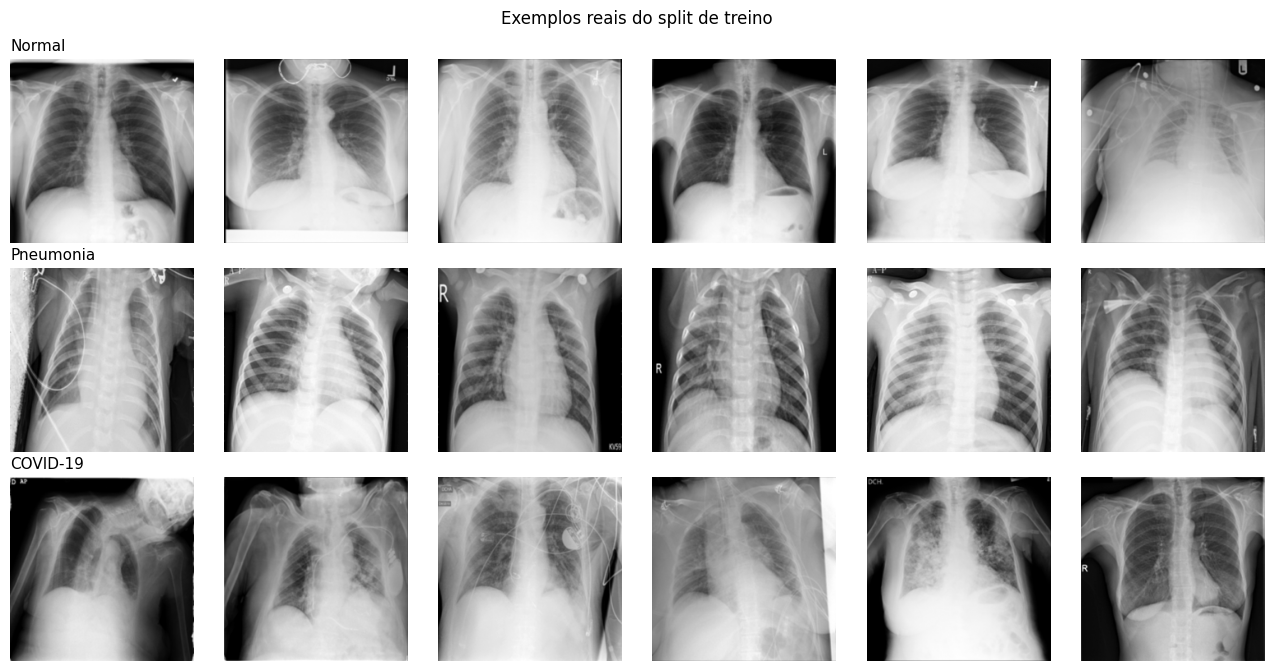

In [5]:
fig, axes = plt.subplots(3, 6, figsize=(13, 6.8))
for r, c in enumerate(CLASSES):
    for k, i in enumerate(rng.choice(np.where(y[tr] == r)[0], 6, replace=False)):
        axes[r, k].imshow(X[tr][i], cmap="gray"); axes[r, k].axis("off")
    axes[r, 0].set_title(c, loc="left", fontsize=11)
plt.suptitle("Exemplos reais do split de treino")
plt.tight_layout(); plt.savefig(FIG_DIR / "exemplos_reais.png", dpi=120); plt.show()

**Por que 60/20/20 e não 80/20.** Com 120 casos COVID-19, um split 80/20 deixa ~24 positivos na validação e
nenhum test set; aqui cada partição de avaliação tem **24 positivos** (val para seleção de modelo, test **só** para
o número final). Cada falso negativo move a recall em ~4 p.p. — por isso o §6 reporta 3 seeds e IC por bootstrap.

**Limitação conhecida do dataset.** As imagens COVID-19 desta base vêm de repositórios diferentes das imagens
Normal/Pneumonia (hospitais, equipamentos, pós-processamento). Um classificador pode aprender **"de qual fonte
veio a imagem"** em vez da patologia (*shortcut learning*, DeGrave et al., 2021). O §6 inclui Grad-CAM para
checar onde o modelo olha.

## 2. Diagnóstico do projeto anterior (≥5 problemas)

| # | Problema | Evidência | Impacto clínico esperado |
|---|---|---|---|
| 1 | **Accuracy global como única métrica** | Um classificador trivial "sempre Normal" tem **70%** de accuracy (840/1200). Os 61% de validação ficam **abaixo** da baseline trivial | A métrica esconde exatamente o erro que importa: um paciente COVID-19 classificado como Normal (falso negativo) não aparece no número. O "promissor" era ilusório |
| 2 | **Desbalanceamento 7:2:1 não tratado** (sem class weights, sampler ou oversampling) | 70% do gradiente vem de Normal; o ótimo local mais barato é prever Normal. É o padrão descrito por Nour & Tariq (2023): recall < 60% para COVID em datasets desbalanceados | Reproduz a queixa do time clínico — o modelo **"ignora casos positivos"**. Paciente infectado liberado sem isolamento → transmissão e atraso no tratamento |
| 3 | **Split 80/20 sem estratificação e sem test set** | Simulação abaixo: o nº de COVID na validação varia entre splits; hiperparâmetros e "último epoch" são escolhidos e reportados no mesmo conjunto | A performance reportada não é uma estimativa confiável do que acontece no hospital; a decisão de implantar é tomada sobre ruído |
| 4 | **ResNet-18 do zero (~11M parâmetros) com ~960 imagens** | Gap treino/val de **32 p.p.** (93% vs 61%) = overfitting severo; sem features pré-treinadas para bordas, texturas e formas | O modelo memoriza artefatos do conjunto (marcadores laterais, texto, bordas, fonte da imagem) e falha em imagens de outro equipamento/hospital |
| 5 | **Sem augmentation** | 120 imagens COVID vistas 15 vezes idênticas; nenhuma invariância a posicionamento, rotação leve ou exposição | Raio-X de COVID em UTI é frequentemente **AP portátil**, com posicionamento e exposição piores — justamente a população de maior risco recebe as imagens mais "fora da distribuição" |
| 6 | **SGD com lr fixo 0,01, 15 epochs, sem scheduler, early stopping ou checkpoint** | Para uma rede do zero, lr fixo alto oscila; 15 epochs é arbitrário; o modelo reportado é o do último epoch, não o melhor na validação | Resultado não reprodutível e instável — dois treinos idênticos podem dar comportamentos clínicos diferentes |
| 7 | **Sem ponto de operação (threshold) definido** | Usou argmax padrão. Triagem exige **alta sensibilidade**: o custo de um FN (COVID liberado) é muito maior que o de um FP (teste RT-PCR extra) | Sem controle explícito do trade-off FN/FP, o sistema não pode ser calibrado para o protocolo clínico |
| 8 | **Sem análise de viés de fonte / interpretabilidade** | Bases públicas de COVID misturam fontes; modelos aprendem atalhos (DeGrave et al., 2021; Roberts et al., 2021) | O modelo pode detectar "hospital X" em vez de "opacidade pulmonar" e falhar silenciosamente em produção |

A célula abaixo quantifica os problemas 1 e 3.

Accuracy de 'sempre Normal': 70.0%  |  validação reportada pelo grupo: 61%
COVID na validação (1000 splits aleatórios): média 23.7, min 13, max 35, P5–P95 = 18–30


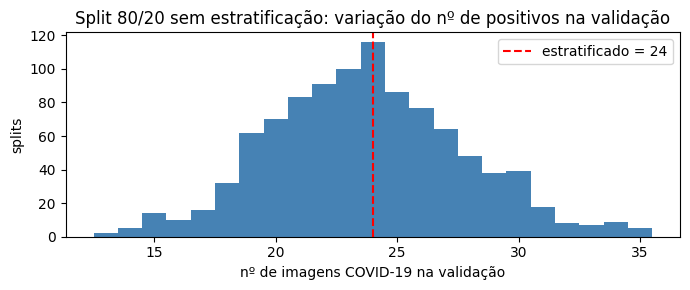

In [6]:
# (1) baseline trivial "sempre Normal"
acc_trivial = (y == 0).mean()
print(f"Accuracy de 'sempre Normal': {acc_trivial:.1%}  |  validação reportada pelo grupo: 61%")

# (3) variância do nº de COVID na validação em splits 80/20 NÃO estratificados
n_cov_val = np.array([(y[train_test_split(idx, test_size=0.2, random_state=s)[1]] == COVID).sum()
                      for s in range(1000)])
print(f"COVID na validação (1000 splits aleatórios): média {n_cov_val.mean():.1f}, "
      f"min {n_cov_val.min()}, max {n_cov_val.max()}, P5–P95 = {np.percentile(n_cov_val, 5):.0f}–{np.percentile(n_cov_val, 95):.0f}")

plt.figure(figsize=(7, 3))
plt.hist(n_cov_val, bins=range(n_cov_val.min(), n_cov_val.max() + 2), color="steelblue", align="left")
plt.axvline(24, color="red", ls="--", label="estratificado = 24")
plt.xlabel("nº de imagens COVID-19 na validação"); plt.ylabel("splits"); plt.legend()
plt.title("Split 80/20 sem estratificação: variação do nº de positivos na validação")
plt.tight_layout(); plt.savefig(FIG_DIR / "split_sem_estratificacao.png", dpi=120); plt.show()

RESULTS["diagnostico"] = dict(acc_sempre_normal=float(acc_trivial), cov_val_mean=float(n_cov_val.mean()),
                              cov_val_min=int(n_cov_val.min()), cov_val_max=int(n_cov_val.max()))

**Análise.** O classificador trivial "sempre Normal" atinge **70%** — os 61% de validação do grupo anterior são
**9 p.p. piores que não fazer nada**, o que por si só invalida o rótulo "promissor". Sobre o split: em 1.000 splits
80/20 aleatórios, o número de COVID-19 na validação variou de **13 a 35** (P5–P95 = 18–30, média 23,7). Com 18
positivos, cada falso negativo move a recall em 5,6 p.p.; com 30, em 3,3 p.p. — **a recall reportada depende tanto
da sorte do split quanto do modelo**. A estratificação fixa esse número em 24 e torna comparações entre
experimentos possíveis.

## 3. Reprodução do protocolo do grupo anterior

Antes de propor melhorias, verifico se as falhas **acontecem de fato** com o protocolo original: ResNet-18
**sem pré-treinamento**, SGD (momentum 0,9 — o enunciado não especifica; é o valor mais comum), lr fixo 0,01,
15 epochs, batch 32, sem augmentation, split 80/20 **não estratificado**, reportando o último epoch.

Os utilitários abaixo (dataset, treino, métricas) são **os mesmos** usados no §6 — só a configuração muda.

In [7]:
IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMNET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Augmentation clínica-plausível: rotação/translação/escala leves, brilho/contraste (exposição) e blur ocasional.
# Sem flip horizontal: inverteria a posição do coração (dextrocardia artificial). Blur também neutraliza o atalho
# "imagem suave = sintética = COVID" quando entram as imagens da GAN (64 px ampliadas).
train_tf = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    T.RandomApply([T.ColorJitter(brightness=0.2, contrast=0.2)], p=0.8),
    T.RandomApply([T.GaussianBlur(kernel_size=9, sigma=(0.5, 2.0))], p=0.3),
])


class XRayDS(Dataset):
    def __init__(self, X, y, tf=None, imagenet_norm=True):
        self.X, self.y, self.tf, self.norm = X, y, tf, imagenet_norm

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = torch.from_numpy(self.X[i]).unsqueeze(0)          # uint8 1×H×W
        if self.tf is not None:
            x = self.tf(x)
        x = (x.float() / 255.0).expand(3, -1, -1)              # cinza -> 3 canais
        if self.norm:
            x = (x - IMNET_MEAN) / IMNET_STD
        return x, int(self.y[i])


def make_loader(X_, y_, tf=None, norm=True, shuffle=False, bs=64, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(XRayDS(X_, y_, tf, norm), batch_size=bs, shuffle=shuffle, generator=g,
                      num_workers=NUM_WORKERS, pin_memory=device == "cuda")


def make_model(pretrained=True):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    return m.to(device)


@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y = [], []
    for x, yb in loader:
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=device == "cuda"):
            logits = model(x.to(device, non_blocking=True))
        P.append(logits.float().softmax(1).cpu()); Y.append(yb)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()


def metrics(probs, y_):
    pred = probs.argmax(1)
    rec = recall_score(y_, pred, labels=[0, 1, 2], average=None, zero_division=0)
    return dict(acc=accuracy_score(y_, pred), bal_acc=balanced_accuracy_score(y_, pred),
                f1_macro=f1_score(y_, pred, average="macro", zero_division=0),
                rec_normal=rec[0], rec_pneumonia=rec[1], rec_covid=rec[2],
                auc_covid=roc_auc_score(y_ == COVID, probs[:, COVID]))


def train_classifier(Xtr, ytr, Xva, yva, *, pretrained=True, opt="adamw", lr=3e-4, epochs=25, aug=True,
                     class_weights=True, scheduler=True, early_stop=True, patience=7, bs=32, seed=SEED):
    set_seed(seed)
    dl_tr = make_loader(Xtr, ytr, train_tf if aug else None, pretrained, shuffle=True, bs=bs, seed=seed)
    dl_va = make_loader(Xva, yva, None, pretrained)
    model = make_model(pretrained)
    w = None
    if class_weights:  # peso inverso à frequência: n / (K · n_c)
        cnt = np.bincount(ytr, minlength=len(CLASSES))
        w = torch.tensor(len(ytr) / (len(CLASSES) * cnt), dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=w)
    if opt == "sgd":
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs) if scheduler else None
    scaler = torch.amp.GradScaler("cuda", enabled=device == "cuda")

    hist, best_f1, best_state, best_ep, bad = [], -1.0, None, 0, 0
    for ep in range(1, epochs + 1):
        model.train(); tl = tc = n = 0
        for x, yb in dl_tr:
            x, yb = x.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=device == "cuda"):
                out = model(x); loss = crit(out, yb)
            optim.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(optim); scaler.update()
            tl += loss.item() * len(yb); tc += (out.argmax(1) == yb).sum().item(); n += len(yb)
        if sched:
            sched.step()
        pv, yv = predict(model, dl_va)
        m = metrics(pv, yv)
        loss_va = F.nll_loss(torch.log(torch.from_numpy(pv) + 1e-8), torch.from_numpy(yv)).item()
        hist.append(dict(epoch=ep, loss_tr=tl / n, acc_tr=tc / n, loss_va=loss_va, **{k + "_va": v for k, v in m.items()}))
        if early_stop:  # checkpoint pelo F1 macro de validação (não pela accuracy)
            if m["f1_macro"] > best_f1:
                best_f1, best_state, best_ep, bad = m["f1_macro"], copy.deepcopy(model.state_dict()), ep, 0
            else:
                bad += 1
                if bad >= patience:
                    break
    if early_stop:
        model.load_state_dict(best_state)
    hist = pd.DataFrame(hist)
    hist.attrs["best_epoch"] = best_ep if early_stop else len(hist)
    return model, hist


def plot_cm(ax, y_, pred, title):
    cm = confusion_matrix(y_, pred, labels=[0, 1, 2])
    ax.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(3), CLASSES, rotation=20); ax.set_yticks(range(3), CLASSES)
    ax.set_xlabel("previsto"); ax.set_ylabel("real"); ax.set_title(title, fontsize=10)


def plot_curves(hist, title, fname):
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
    ax[0].plot(hist.epoch, hist.loss_tr, label="treino"); ax[0].plot(hist.epoch, hist.loss_va, label="val")
    ax[0].set_title("loss"); ax[0].legend()
    ax[1].plot(hist.epoch, hist.acc_tr, label="treino"); ax[1].plot(hist.epoch, hist.acc_va, label="val")
    ax[1].set_title("accuracy"); ax[1].legend()
    ax[2].plot(hist.epoch, hist.rec_covid_va, label="recall COVID (val)", color="crimson")
    ax[2].plot(hist.epoch, hist.f1_macro_va, label="F1 macro (val)", color="gray")
    ax[2].set_ylim(0, 1.02); ax[2].set_title("métricas por classe"); ax[2].legend()
    for a in ax:
        a.set_xlabel("epoch")
    plt.suptitle(title); plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=120); plt.show()

Validação do baseline por classe: {'Normal': 168, 'Pneumonia': 52, 'COVID-19': 20}
Reportado pelo grupo: acc treino 0,93 | acc validação 0,61 | baseline trivial 0,70

                        acc  bal_acc  f1_macro  rec_normal  rec_pneumonia  rec_covid  auc_covid
treino (reprodução)     1.0    1.000     1.000        1.00          1.000        1.0      1.000
validação (reprodução)  0.9    0.725     0.749        0.97          0.904        0.3      0.927


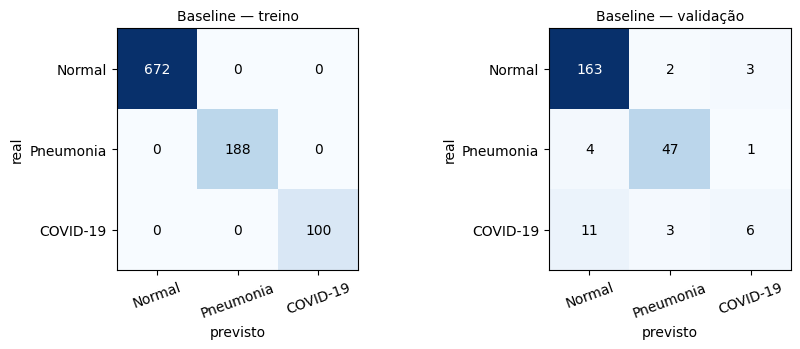

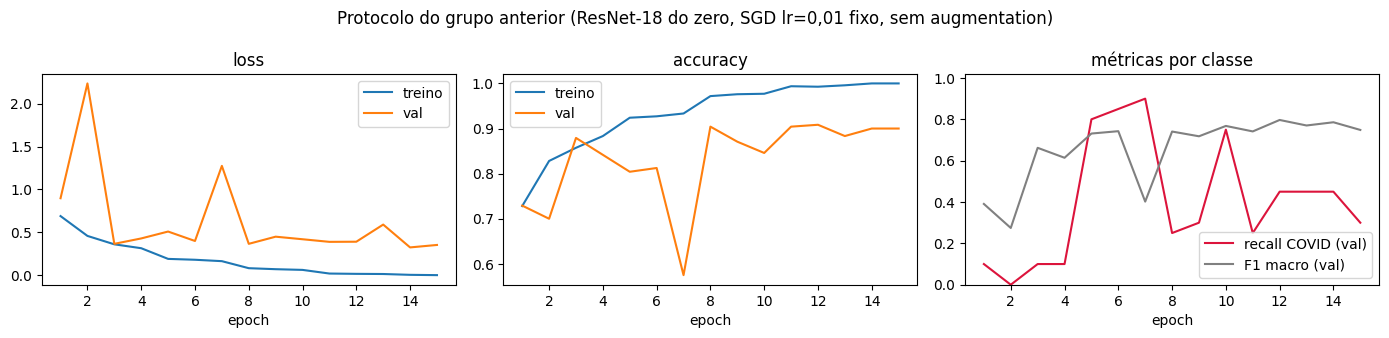

In [8]:
t0 = time.time()
b_tr, b_va = train_test_split(idx, test_size=0.2, random_state=SEED)   # SEM stratify, como o grupo anterior
print("Validação do baseline por classe:", dict(zip(CLASSES, np.bincount(y[b_va], minlength=3).tolist())))

base_model, base_hist = train_classifier(X[b_tr], y[b_tr], X[b_va], y[b_va], pretrained=False, opt="sgd", lr=0.01,
                                         epochs=15, aug=False, class_weights=False, scheduler=False, early_stop=False)
p_btr, _ = predict(base_model, make_loader(X[b_tr], y[b_tr], norm=False))
p_bva, _ = predict(base_model, make_loader(X[b_va], y[b_va], norm=False))
m_btr, m_bva = metrics(p_btr, y[b_tr]), metrics(p_bva, y[b_va])

res_tab = pd.DataFrame([m_btr, m_bva], index=["treino (reprodução)", "validação (reprodução)"]).round(3)
print("Reportado pelo grupo: acc treino 0,93 | acc validação 0,61 | baseline trivial 0,70\n")
print(res_tab.to_string())
RESULTS["baseline_reproducao"] = {"treino": m_btr, "val": m_bva}

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
plot_cm(ax[0], y[b_tr], p_btr.argmax(1), "Baseline — treino")
plot_cm(ax[1], y[b_va], p_bva.argmax(1), "Baseline — validação")
plt.tight_layout(); plt.savefig(FIG_DIR / "baseline_confusao.png", dpi=120); plt.show()
plot_curves(base_hist, "Protocolo do grupo anterior (ResNet-18 do zero, SGD lr=0,01 fixo, sem augmentation)",
            "baseline_curvas.png")
TIMES["3_baseline"] = time.time() - t0

**Análise.** A reprodução **não** repetiu os 61% de validação: deu **100% de accuracy no treino e 90% na
validação**. Mas repetiu exatamente a queixa clínica: **recall COVID-19 = 0,30** (6 de 20 casos detectados),
balanced accuracy 0,72. Os 90% de accuracy — que pareceriam ótimos num relatório — convivem com um modelo que
**deixa passar 70% dos pacientes COVID**, porque 168 das 240 imagens de validação são Normal. É a ilustração mais
direta do problema 1: a accuracy global esconde o erro que importa.

Outros problemas do §2 aparecem nas curvas:
- **Overfitting (problema 4):** accuracy de treino chega a 100% e a loss de treino a ~0, enquanto a loss de
  validação oscila e não acompanha.
- **LR fixo sem checkpoint (problema 6):** a recall COVID na validação salta entre 0,0 e 0,9 de um epoch para o
  outro (0,90 no epoch 7, 0,25 no epoch 8). Reportar "o último epoch" é sortear um desses valores.
- **Split não estratificado (problema 3):** esta validação tem 20 COVID, não 24 — mesmo corpus, outro número.

A diferença para os 61% originais é provável efeito do dataset: esta base pública é "mais fácil" que a do grupo
(imagens de fontes distintas por classe — o próprio viés de fonte do problema 8). Isso reforça o ponto: **accuracy
alta não é evidência de que o modelo aprendeu a patologia**.

## 4. GAN condicional (cDCGAN) para raio-X

**Escolha: GAN condicional em vez de CycleGAN.** O problema é **escassez** de uma classe, não tradução entre
domínios. Uma CycleGAN Normal→COVID exigiria dois pares gerador/discriminador e, com 72 imagens COVID de treino,
tenderia a apenas "pintar" opacidades sobre anatomia Normal (risco de atalho). A cGAN aprende a distribuição
condicional `p(x | classe)` compartilhando o aprendizado de anatomia torácica entre as três classes — as 504
imagens Normal ajudam o gerador a aprender pulmões, costelas e mediastino, e o rótulo especializa a patologia.

**Arquitetura (DCGAN, Radford et al., 2016), 64×64, 1 canal:**
- **G**: `z ∈ R^100` ⊕ `embedding(classe) ∈ R^50` → 4 `ConvTranspose2d` com BatchNorm + ReLU → `Tanh`.
- **D**: imagem ⊕ mapa do rótulo (embedding → 64×64, 1 canal extra) → 4 `Conv2d` stride 2 + LeakyReLU(0,2) → logit.
- **64×64** cabe com folga na T4 e treina em minutos; o custo é perda de detalhe fino (discutido no §6).

**Loop adversarial** (por iteração): (1) passo do **D** com `BCE(D(x_real), 1) + BCE(D(G(z).detach()), 0)`;
(2) passo do **G** com `BCE(D(G(z)), 1)` (loss *não saturante*). `detach()` no passo do D impede que o gradiente
do D atualize o G. Batches **balanceados por classe** para que COVID-19 receba 1/3 do treino adversarial.

**GAN treinada só no split de treino** — val/test nunca são vistos pelo gerador (sem vazamento para o §6).

In [9]:
GAN_RES, NZ, EMB = 64, 100, 50
GAN_ITERS = 5000
GAN_BS = 64


def to_gan(Xu8):  # uint8 N×224×224 -> float N×1×64×64 em [-1, 1]
    t = torch.from_numpy(Xu8).float().unsqueeze(1) / 127.5 - 1
    return F.interpolate(t, size=GAN_RES, mode="area")


Xg_tr, yg_tr = to_gan(X[tr]).to(device), torch.from_numpy(y[tr]).to(device)
Xg_va, yg_va = to_gan(X[va]).to(device), torch.from_numpy(y[va]).to(device)
_cls_idx = [torch.where(yg_tr == c)[0] for c in range(3)]
_cls_cnt = torch.tensor([len(i) for i in _cls_idx], device=device)
_cls_mat = torch.stack([F.pad(i, (0, int(_cls_cnt.max()) - len(i))) for i in _cls_idx])


def sample_real(bs):  # batch balanceado por classe
    c = torch.randint(0, 3, (bs,), device=device)
    r = (torch.rand(bs, device=device) * _cls_cnt[c]).long()
    i = _cls_mat[c, r]
    return Xg_tr[i], yg_tr[i]


class CondGenerator(nn.Module):
    def __init__(self, ngf=64):
        super().__init__()
        self.emb = nn.Embedding(3, EMB)

        def up(i, o):
            return [nn.ConvTranspose2d(i, o, 4, 2, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True)]
        self.net = nn.Sequential(
            nn.ConvTranspose2d(NZ + EMB, ngf * 8, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf * 8), nn.ReLU(True),  # 4
            *up(ngf * 8, ngf * 4), *up(ngf * 4, ngf * 2), *up(ngf * 2, ngf),                                   # 32
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1, bias=False), nn.Tanh())                                       # 64

    def forward(self, z, c):
        return self.net(torch.cat([z, self.emb(c)], 1)[..., None, None])


class CondDiscriminator(nn.Module):
    def __init__(self, ndf=64, spectral=False):
        super().__init__()
        SN = nn.utils.spectral_norm if spectral else (lambda m: m)
        self.emb = nn.Embedding(3, GAN_RES * GAN_RES)

        def down(i, o, bn):
            layers = [SN(nn.Conv2d(i, o, 4, 2, 1, bias=not bn))]
            return layers + ([nn.BatchNorm2d(o)] if bn else []) + [nn.LeakyReLU(0.2, True)]
        bn = not spectral  # com spectral norm, sem BatchNorm no D (Miyato et al., 2018)
        self.net = nn.Sequential(*down(2, ndf, False), *down(ndf, ndf * 2, bn), *down(ndf * 2, ndf * 4, bn),
                                 *down(ndf * 4, ndf * 8, bn), SN(nn.Conv2d(ndf * 8, 1, 4, 1, 0)))

    def forward(self, x, c):
        return self.net(torch.cat([x, self.emb(c).view(-1, 1, GAN_RES, GAN_RES)], 1)).view(-1)


def weights_init(m):  # DCGAN: N(0, 0.02)
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight_orig if hasattr(m, "weight_orig") else m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02); nn.init.zeros_(m.bias)


def diff_augment(x):
    """DiffAugment (Zhao et al., 2020): brilho, contraste, translação 1/8 e cutout 1/2 — diferenciáveis,
    aplicados a reais E falsas, no passo do D e do G."""
    B = x.size(0)
    x = x + (torch.rand(B, 1, 1, 1, device=x.device) - 0.5)
    m = x.mean(dim=[1, 2, 3], keepdim=True)
    x = (x - m) * (torch.rand(B, 1, 1, 1, device=x.device) + 0.5) + m
    theta = torch.zeros(B, 2, 3, device=x.device); theta[:, 0, 0] = theta[:, 1, 1] = 1
    theta[:, :, 2] = (torch.rand(B, 2, device=x.device) - 0.5) * 0.5          # ±1/8 da imagem
    x = F.grid_sample(x, F.affine_grid(theta, x.shape, align_corners=False), padding_mode="zeros", align_corners=False)
    s = GAN_RES // 2
    cy, cx = torch.randint(0, GAN_RES, (2, B, 1, 1), device=x.device)
    yy, xx = torch.arange(GAN_RES, device=x.device).view(1, -1, 1), torch.arange(GAN_RES, device=x.device).view(1, 1, -1)
    mask = ~(((yy - cy).abs() < s // 2) & ((xx - cx).abs() < s // 2))
    return x * mask.unsqueeze(1)


def _gauss_win(ws=7, sigma=1.5):
    g = torch.exp(-(torch.arange(ws) - ws // 2).float() ** 2 / (2 * sigma ** 2)); g = g / g.sum()
    return (g[:, None] * g[None, :])[None, None]


def ssim(a, b):  # N×1×H×W em [0, 1]
    w = _gauss_win().to(a.device); C1, C2 = 0.01 ** 2, 0.03 ** 2
    mu_a, mu_b = F.conv2d(a, w), F.conv2d(b, w)
    s_aa, s_bb = F.conv2d(a * a, w) - mu_a ** 2, F.conv2d(b * b, w) - mu_b ** 2
    s_ab = F.conv2d(a * b, w) - mu_a * mu_b
    m = ((2 * mu_a * mu_b + C1) * (2 * s_ab + C2)) / ((mu_a ** 2 + mu_b ** 2 + C1) * (s_aa + s_bb + C2))
    return m.mean(dim=[1, 2, 3])


@torch.no_grad()
def mean_pairwise_ssim(x):
    """Diversidade: SSIM médio entre pares. ~1 = amostras iguais (mode collapse)."""
    x = ((x + 1) / 2).to(device); i, j = torch.triu_indices(len(x), len(x), 1)
    return torch.cat([ssim(x[i[k:k + 512]], x[j[k:k + 512]]) for k in range(0, len(i), 512)]).mean().item()


@torch.no_grad()
def generate(G, cls, n, seed=SEED, bs=128):
    G.eval(); g = torch.Generator(device=device).manual_seed(seed); out = []
    for k in range(0, n, bs):
        m = min(bs, n - k)
        z = torch.randn(m, NZ, device=device, generator=g)
        out.append(G(z, torch.full((m,), cls, device=device, dtype=torch.long)).float().cpu())
    G.train()
    return torch.cat(out)


def train_gan(cfg, iters=GAN_ITERS, bs=GAN_BS, log_every=25, eval_every=500):
    set_seed(SEED)
    G, D = CondGenerator().to(device), CondDiscriminator(spectral=cfg["sn"]).to(device)
    G.apply(weights_init); D.apply(weights_init)
    optG = torch.optim.Adam(G.parameters(), lr=cfg["lr_g"], betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=cfg["lr_d"], betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    aug = diff_augment if cfg["diffaug"] else (lambda t: t)
    fixed_z = torch.randn(24, NZ, device=device, generator=torch.Generator(device=device).manual_seed(0))
    fixed_c = torch.arange(3, device=device).repeat_interleave(8)
    log, evals, snaps = [], [], {}
    t0 = time.time()
    for it in range(1, iters + 1):
        x, c = sample_real(bs)
        z = torch.randn(bs, NZ, device=device)
        fake = G(z, c)
        # ---- passo do D: reais -> real_label (1.0 ou 0.9 com label smoothing), falsas -> 0
        d_real, d_fake = D(aug(x), c), D(aug(fake.detach()), c)
        loss_d = bce(d_real, torch.full_like(d_real, cfg["real_label"])) + bce(d_fake, torch.zeros_like(d_fake))
        optD.zero_grad(set_to_none=True); loss_d.backward(); optD.step()
        # ---- passo do G: loss não saturante, falsas -> 1
        d_gen = D(aug(fake), c)
        loss_g = bce(d_gen, torch.ones_like(d_gen))
        optG.zero_grad(set_to_none=True); loss_g.backward(); optG.step()

        if it % log_every == 0:
            log.append(dict(it=it, loss_d=loss_d.item(), loss_g=loss_g.item(),
                            D_x=torch.sigmoid(d_real).mean().item(), D_Gz=torch.sigmoid(d_fake).mean().item()))
        if it % eval_every == 0 or it == iters:
            with torch.no_grad():
                sel = torch.randperm(len(Xg_tr), device=device)[:len(Xg_va)]
                s_tr = torch.sigmoid(D(Xg_tr[sel], yg_tr[sel])).mean().item()
                s_va = torch.sigmoid(D(Xg_va, yg_va)).mean().item()
                G.eval(); snaps[it] = G(fixed_z, fixed_c).float().cpu(); G.train()
            evals.append(dict(it=it, D_train=s_tr, D_heldout=s_va, D_gap=s_tr - s_va,
                              div_ssim_covid=mean_pairwise_ssim(generate(G, COVID, 64, seed=it))))
    print(f"{cfg['name']}: {iters} iterações em {time.time() - t0:.0f}s")
    return dict(cfg=cfg, G=G, log=pd.DataFrame(log), evals=pd.DataFrame(evals), snaps=snaps)

## 5. Instabilidade: diagnóstico e mitigação

Com ~720 imagens (72 COVID), a falha esperada de uma GAN é o **D memorizar o conjunto de treino** (Karras et al.,
2020): D(x_real) → 1, D(G(z)) → 0, a loss do G sobe/oscila e o G deixa de receber gradiente útil — o que leva a
**divergência** e/ou **mode collapse** (G produz poucas variações).

**Sinais medidos** (não só "olhar as imagens"):
- curvas `loss_D`, `loss_G`, `D(x)`, `D(G(z))`;
- **overfitting do D**: `D_gap = E[D(x_treino)] − E[D(x_heldout)]` em imagens reais nunca vistas — D memorizando → gap cresce;
- **diversidade**: SSIM médio entre pares de 64 amostras COVID (≈1 → colapso), comparado ao SSIM entre imagens reais;
- **KID** (Kernel Inception Distance, Bińkowski et al., 2018) — preferido ao FID porque é não enviesado para
  amostras pequenas (só 72 COVID reais de treino); ×10³, menor é melhor;
- **memorização**: distância ao vizinho mais próximo do treino (amostra sintética vs. imagem real de val).

| Run | Configuração | Papel |
|---|---|---|
| **A** | DCGAN vanilla: BatchNorm no D, lr 2e-4 / 2e-4, rótulo real = 1,0, sem augmentation | diagnóstico |
| **A+SN** | A + spectral norm no D (sem BN) | ablação |
| **A+DiffAug** | A + DiffAugment | ablação |
| **B** | Spectral norm + DiffAugment + label smoothing unilateral (0,9) + TTUR (lr_D 4e-4 / lr_G 1e-4) | mitigação completa |

**Por que cada mitigação:** *spectral norm* limita a constante de Lipschitz do D (gradientes estáveis para o G);
*DiffAugment* impede o D de memorizar as poucas imagens reais sem vazar augmentation para o G; *label smoothing*
evita que o D fique superconfiante; *TTUR* (Heusel et al., 2017) deixa o D aprender mais rápido que o G para que o
G sempre receba um sinal atualizado.

In [10]:
t0 = time.time()
GAN_CFGS = [
    dict(name="A (vanilla)", sn=False, diffaug=False, real_label=1.0, lr_g=2e-4, lr_d=2e-4),
    dict(name="A+SN", sn=True, diffaug=False, real_label=1.0, lr_g=2e-4, lr_d=2e-4),
    dict(name="A+DiffAug", sn=False, diffaug=True, real_label=1.0, lr_g=2e-4, lr_d=2e-4),
    dict(name="B (mitigada)", sn=True, diffaug=True, real_label=0.9, lr_g=1e-4, lr_d=4e-4),
]
gan_runs = {cfg["name"]: train_gan(cfg) for cfg in GAN_CFGS}
TIMES["5_gan_treino"] = time.time() - t0

A (vanilla): 5000 iterações em 369s
A+SN: 5000 iterações em 386s
A+DiffAug: 5000 iterações em 378s
B (mitigada): 5000 iterações em 390s


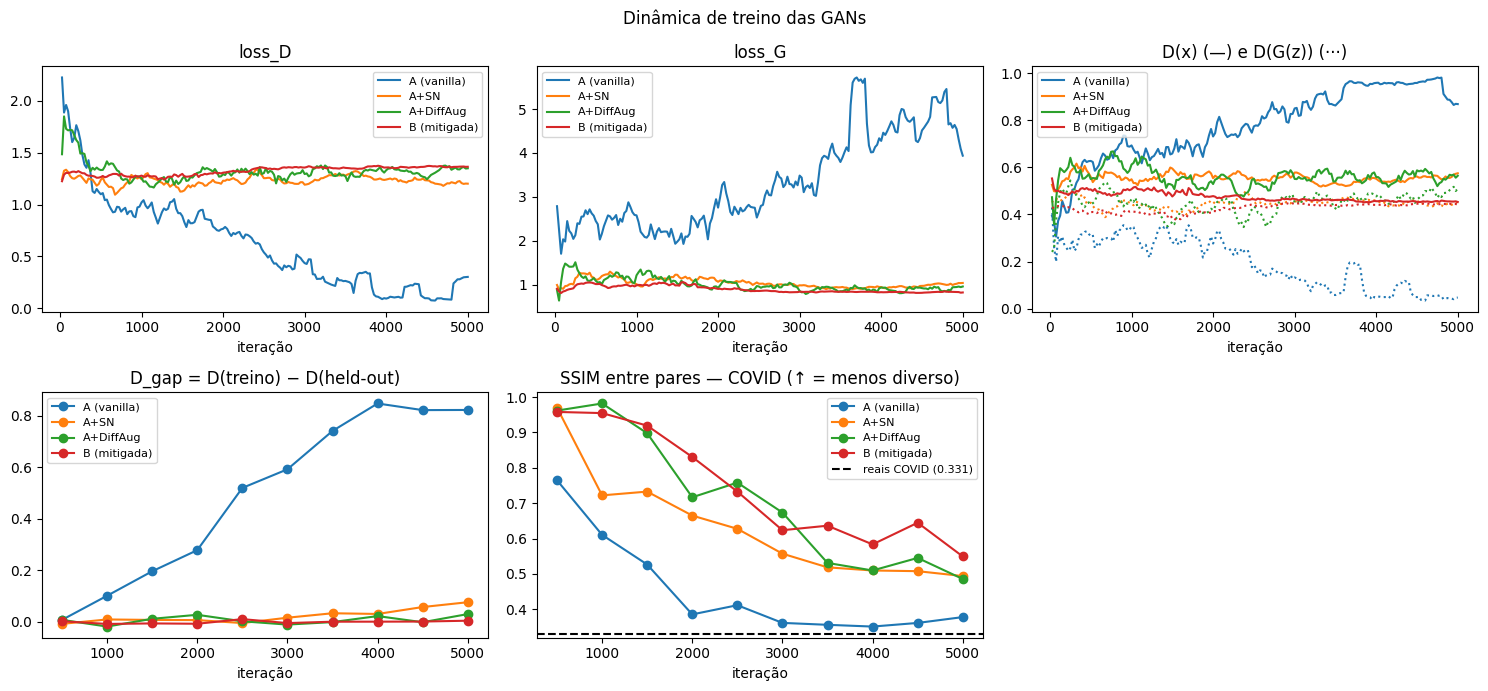

In [11]:
def smooth(s, k=8):
    return s.rolling(k, min_periods=1).mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for name, r in gan_runs.items():
    L, E = r["log"], r["evals"]
    axes[0, 0].plot(L.it, smooth(L.loss_d), label=name); axes[0, 1].plot(L.it, smooth(L.loss_g), label=name)
    axes[0, 2].plot(L.it, smooth(L.D_x), label=name); axes[0, 2].plot(L.it, smooth(L.D_Gz), ls=":", color=axes[0, 2].lines[-1].get_color())
    axes[1, 0].plot(E.it, E.D_gap, marker="o", label=name)
    axes[1, 1].plot(E.it, E.div_ssim_covid, marker="o", label=name)
real_div = mean_pairwise_ssim(Xg_tr[yg_tr == COVID][:64].cpu())
axes[1, 1].axhline(real_div, color="k", ls="--", label=f"reais COVID ({real_div:.3f})")
for a, t in zip(axes.ravel(), ["loss_D", "loss_G", "D(x) (—) e D(G(z)) (···)", "D_gap = D(treino) − D(held-out)",
                                "SSIM entre pares — COVID (↑ = menos diverso)"]):
    a.set_title(t); a.set_xlabel("iteração"); a.legend(fontsize=8)
axes[1, 2].axis("off")
plt.suptitle("Dinâmica de treino das GANs"); plt.tight_layout()
plt.savefig(FIG_DIR / "gan_curvas.png", dpi=120); plt.show()

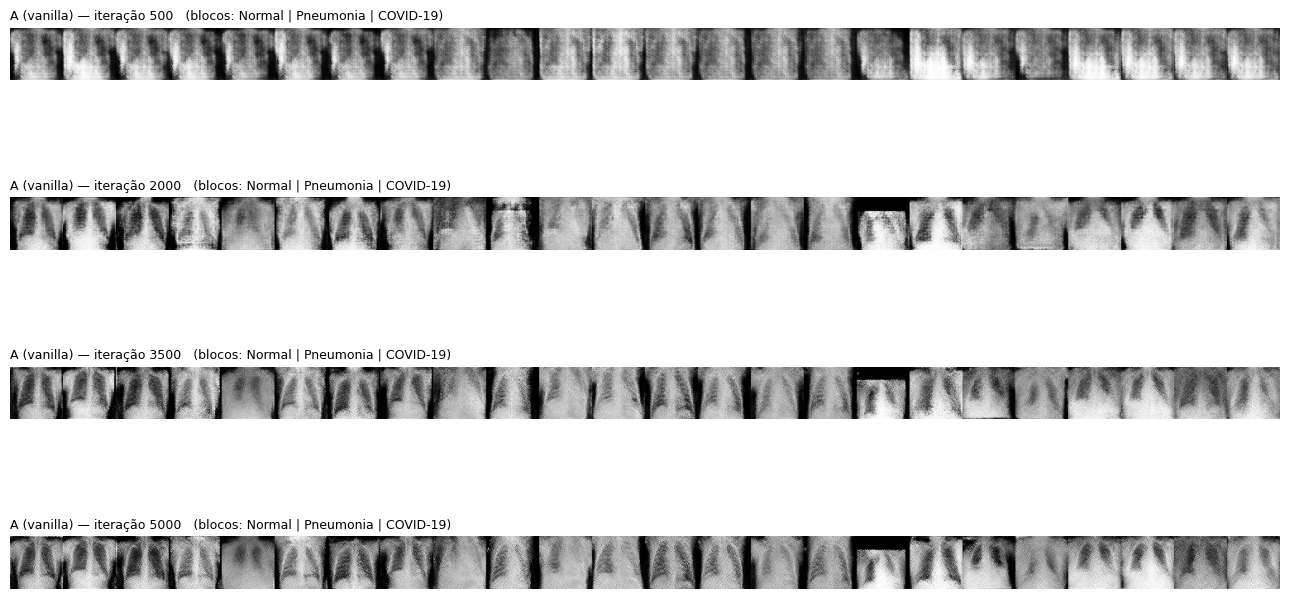

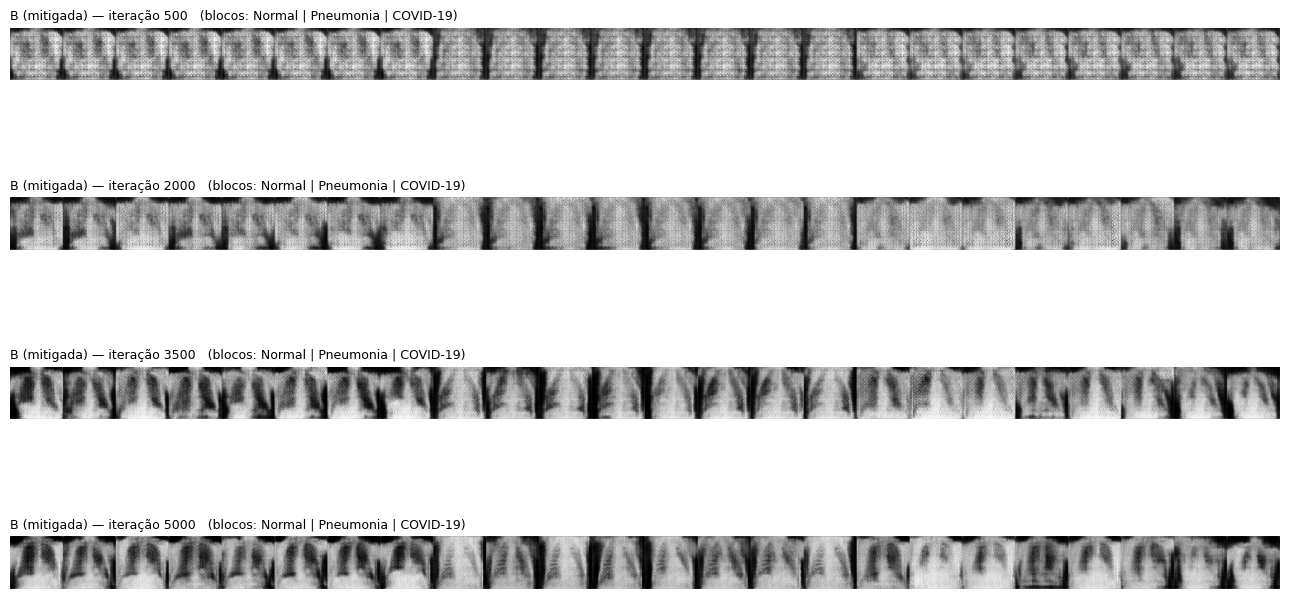

In [12]:
def show_snaps(r, its, fname):
    fig, axes = plt.subplots(len(its), 1, figsize=(13, 1.9 * len(its)))
    for a, it in zip(np.atleast_1d(axes), its):
        s = (r["snaps"][it] + 1) / 2                               # 24 = 8 por classe
        grid = torch.cat([torch.cat(list(s[k * 8:(k + 1) * 8, 0]), 1) for k in range(3)], 1)
        a.imshow(grid, cmap="gray", vmin=0, vmax=1); a.axis("off")
        a.set_title(f"{r['cfg']['name']} — iteração {it}   (blocos: Normal | Pneumonia | COVID-19)", fontsize=9, loc="left")
    plt.tight_layout(); plt.savefig(FIG_DIR / fname, dpi=110); plt.show()

its = sorted(gan_runs["B (mitigada)"]["snaps"])
its_show = [its[0], its[len(its) // 3], its[2 * len(its) // 3], its[-1]]
for name, fname in [("A (vanilla)", "gan_evolucao_A.png"), ("B (mitigada)", "gan_evolucao_B.png")]:
    show_snaps(gan_runs[name], its_show, fname)

In [13]:
t0 = time.time()
_inc = None

@torch.no_grad()
def inception_feats(x):  # N×1×h×w em [-1, 1] -> N×2048
    global _inc
    if _inc is None:
        _inc = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        _inc.fc = nn.Identity(); _inc = _inc.to(device).eval()
    feats = []
    for b in x.split(100):
        b = F.interpolate(((b + 1) / 2).expand(-1, 3, -1, -1).to(device), size=299, mode="bilinear", align_corners=False)
        feats.append(_inc((b - IMNET_MEAN.to(device)) / IMNET_STD.to(device)).float().cpu())
    return torch.cat(feats).numpy().astype(np.float64)


def kid(f_real, f_fake, n_sub=50, seed=SEED):
    """KID não enviesado, kernel polinomial cúbico, média ± dp sobre subconjuntos (×10³)."""
    rng_ = np.random.default_rng(seed); d = f_real.shape[1]; m = min(len(f_real), len(f_fake)); vals = []
    for _ in range(n_sub):
        a = f_real[rng_.choice(len(f_real), m, replace=False)]; b = f_fake[rng_.choice(len(f_fake), m, replace=False)]
        kaa, kbb, kab = (a @ a.T / d + 1) ** 3, (b @ b.T / d + 1) ** 3, (a @ b.T / d + 1) ** 3
        vals.append((kaa.sum() - np.trace(kaa)) / (m * (m - 1)) + (kbb.sum() - np.trace(kbb)) / (m * (m - 1)) - 2 * kab.mean())
    return 1e3 * float(np.mean(vals)), 1e3 * float(np.std(vals))


real_cov_tr = Xg_tr[yg_tr == COVID].cpu(); real_cov_va = Xg_va[yg_va == COVID].cpu()
f_real_tr = inception_feats(real_cov_tr)
kid_ref = kid(f_real_tr, inception_feats(real_cov_va))            # piso: real (val) vs real (treino)


def nn_dist(a, ref):  # distância L2 (pixels 64×64) ao vizinho mais próximo em ref
    return torch.cdist(a.flatten(1), ref.flatten(1)).min(1).values.numpy()

nn_ref = nn_dist(real_cov_va, real_cov_tr).mean()               # real nunca visto -> treino
rows = []
for name, r in gan_runs.items():
    s = generate(r["G"], COVID, 300)
    k_mean, k_std = kid(f_real_tr, inception_feats(s))
    rows.append(dict(run=name, KID_x1e3=k_mean, KID_std=k_std, div_ssim=mean_pairwise_ssim(s[:64]),
                     D_gap_final=r["evals"].D_gap.iloc[-1], nn_dist_sint=nn_dist(s, real_cov_tr).mean()))
gan_tab = pd.DataFrame(rows).set_index("run")
gan_tab.loc["referência: reais (val)"] = [kid_ref[0], kid_ref[1], mean_pairwise_ssim(real_cov_va), np.nan, nn_ref]
print(gan_tab.round(4).to_string())

BEST_GAN = gan_tab.drop("referência: reais (val)").KID_x1e3.idxmin()
print(f"\nGerador escolhido para o §6 (menor KID COVID): {BEST_GAN}")
G_best = gan_runs[BEST_GAN]["G"]
RESULTS["gan"] = gan_tab.reset_index().to_dict(orient="records"); RESULTS["gan_escolhida"] = BEST_GAN
TIMES["5_gan_avaliacao"] = time.time() - t0

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 188MB/s]


                         KID_x1e3  KID_std  div_ssim  D_gap_final  nn_dist_sint
run                                                                            
A (vanilla)              199.7563   5.6207    0.3927       0.8223       18.6925
A+SN                     243.2183   4.7264    0.4821       0.0757       17.5870
A+DiffAug                230.1373   6.2218    0.4977       0.0297       18.7935
B (mitigada)             241.7395   5.4342    0.5787       0.0040       20.8569
referência: reais (val)   -3.5301   2.5298    0.3407          NaN       18.6260

Gerador escolhido para o §6 (menor KID COVID): A (vanilla)


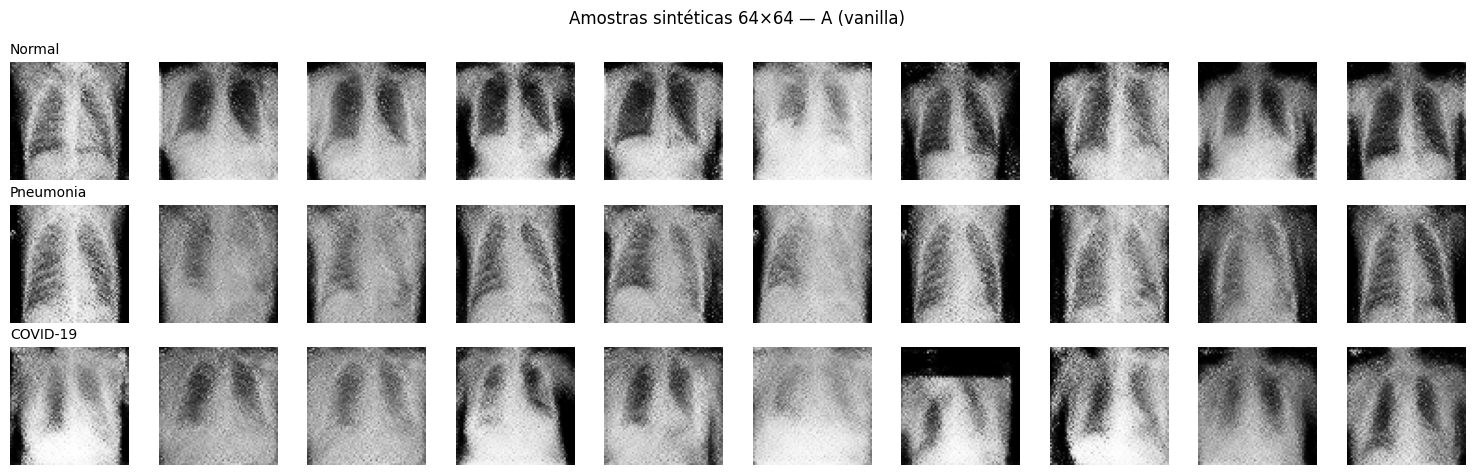

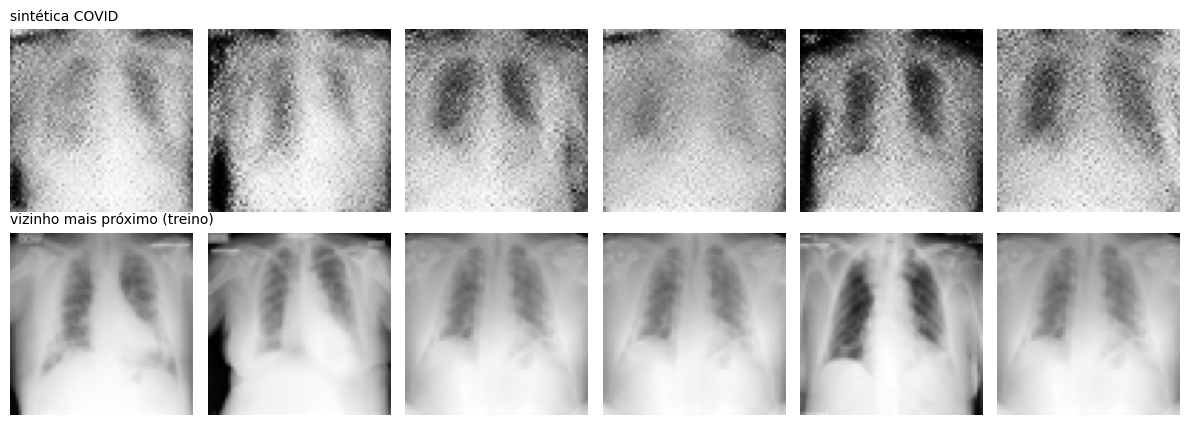

In [14]:
# Amostras finais do gerador escolhido + vizinho mais próximo no treino (checagem de memorização)
fig, axes = plt.subplots(3, 10, figsize=(15, 4.8))
for c in range(3):
    s = generate(G_best, c, 10, seed=123)
    for k in range(10):
        axes[c, k].imshow((s[k, 0] + 1) / 2, cmap="gray", vmin=0, vmax=1); axes[c, k].axis("off")
    axes[c, 0].set_title(CLASSES[c], loc="left", fontsize=10)
plt.suptitle(f"Amostras sintéticas 64×64 — {BEST_GAN}"); plt.tight_layout()
plt.savefig(FIG_DIR / "gan_amostras_finais.png", dpi=120); plt.show()

s = generate(G_best, COVID, 6, seed=7)
nn_i = torch.cdist(s.flatten(1), real_cov_tr.flatten(1)).argmin(1)
fig, axes = plt.subplots(2, 6, figsize=(12, 4.3))
for k in range(6):
    axes[0, k].imshow((s[k, 0] + 1) / 2, cmap="gray"); axes[1, k].imshow((real_cov_tr[nn_i[k], 0] + 1) / 2, cmap="gray")
    axes[0, k].axis("off"); axes[1, k].axis("off")
axes[0, 0].set_title("sintética COVID", loc="left", fontsize=10); axes[1, 0].set_title("vizinho mais próximo (treino)", loc="left", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "gan_vizinho_mais_proximo.png", dpi=120); plt.show()

**Análise — diagnóstico da Run A (vanilla).** A instabilidade aparece com clareza e segue o padrão esperado para
poucos dados, **divergência por overfitting do D** (não mode collapse):
- `loss_D` cai de ~2 para **~0,1–0,3** a partir de ~3.500 iterações, enquanto `loss_G` sobe de ~2,5 para **~5,5**;
- `D(x) → ~0,95` e `D(G(z)) → ~0,05`: o D separa real de falso quase perfeitamente e o G passa a receber gradiente
  fraco e ruidoso;
- **D_gap sobe de 0 para 0,82**: o D dá score alto às imagens de treino e baixo a imagens reais *nunca vistas* —
  ele **memorizou o conjunto de treino** em vez de aprender "o que é um raio-X".
- A diversidade **não** colapsou (SSIM entre pares 0,38 vs. 0,33 das reais), mas as amostras têm **ruído granulado de
  alta frequência**, típico de um G guiado por um D sobreajustado.

**Mitigação — evidência de melhoria na estabilidade.** As três configurações com mitigação eliminam a divergência:
`loss_D` fica estável em ~1,2–1,37 (perto do equilíbrio teórico 2·ln 2 ≈ 1,39), `D(x)` e `D(G(z))` ficam próximos de
0,5 durante todo o treino e o **D_gap fica em ~0** (A+SN 0,076; A+DiffAug 0,030; **B 0,004** vs. **0,82** na
vanilla). A ablação mostra que **spectral norm e DiffAugment, cada um sozinho, já resolvem a divergência**;
combinados (B) dão o menor D_gap.

**Mas a mitigação não melhorou a fidelidade no mesmo orçamento.** KID COVID: vanilla **200** vs. B **242** (×10³;
referência real-vs-real ≈ 0). Diversidade: B 0,58 vs. vanilla 0,38. A curva de SSIM da B ainda estava **caindo**
em 5.000 iterações (0,96 → 0,55): com lr do G reduzido à metade (TTUR) e um D regularizado, o G aprende mais
devagar — a B está **subtreinada, não instável**. A vanilla, por outro lado, chega a 5.000 iterações com amostras
aceitáveis, mas numa trajetória de divergência (D_gap saturado, `loss_G` crescente) — continuar treinando tende a
piorar. O trade-off é estabilidade × velocidade de convergência; o próximo passo seria treinar a B por 15–20 mil
iterações.

**Escolha para o §6:** o critério objetivo pré-definido (menor KID) escolheu a **vanilla**. Mantive o critério para
não escolher o gerador olhando o resultado do classificador.

**Memorização:** a distância média de cada sintética ao vizinho mais próximo do treino (17,6–20,9) é igual à de
imagens reais de validação (18,6) — **nenhuma cópia** das 72 imagens COVID. Na figura de vizinhos, várias sintéticas
diferentes caem no mesmo vizinho real (uma imagem "média"), outro sinal de que não são cópias.

**Qualidade clínica:** em 64×64 o G reproduz forma torácica, campos pulmonares, mediastino e diferença grosseira
entre classes (Pneumonia/COVID mais opacas), mas **não** padrões finos como vidro fosco periférico — o que limita o
valor diagnóstico das sintéticas.

## 6. Experimento: classificador **com vs. sem** imagens sintéticas

**Classificador melhorado (idêntico em todos os braços)** — corrige os problemas 2, 4, 5 e 6 do §2:
ResNet-18 **pré-treinada no ImageNet** com fine-tuning completo (pouco dado → features pré-treinadas; ResNet-18 é
leve para a T4 e comparável ao projeto original), AdamW lr 3e-4 + cosine, **class weights** inversos à
frequência, augmentation clínica (§3), até 25 epochs com **early stopping pelo F1 macro de validação**.

| Braço | Treino | COVID no treino |
|---|---|---|
| **real** | 720 imagens reais | 72 |
| **+1× sintéticas** | reais + 72 COVID sintéticas | 144 (= Pneumonia) |
| **+3× sintéticas** | reais + 216 COVID sintéticas | 288 |

Controle experimental: mesmo split, mesmos hiperparâmetros, **3 seeds** por braço, sintéticas **só no treino**;
val para early stopping; **test (24 COVID) tocado apenas para o número final**. Métrica principal: **recall
COVID-19**; também F1 macro, balanced accuracy e AUC COVID-vs-resto. Sintéticas são geradas em 64×64 e
ampliadas para 224 (bilinear) — o blur aleatório na augmentation impede que "suavidade" vire pista de classe.

In [15]:
t0 = time.time()
SEEDS = [0, 1, 2]
EPOCHS = 25
n_cov_tr = int((y[tr] == COVID).sum())
ARMS = {"real": 0, "+1× sintéticas": n_cov_tr, "+3× sintéticas": 3 * n_cov_tr}


def gan_to_u8(t):  # [-1,1] N×1×64×64 -> uint8 N×224×224
    t = F.interpolate((t + 1) / 2, size=IMG, mode="bilinear", align_corners=False).clamp(0, 1)
    return (t * 255).round().byte().squeeze(1).numpy()

syn_u8 = gan_to_u8(generate(G_best, COVID, max(ARMS.values()), seed=2024))
dl_va, dl_te = make_loader(X[va], y[va]), make_loader(X[te], y[te])

runs, hists, val_probs, test_probs, states = [], {}, {}, {}, {}
for arm, n_syn in ARMS.items():
    Xa = np.concatenate([X[tr], syn_u8[:n_syn]]); ya = np.concatenate([y[tr], np.full(n_syn, COVID)])
    for s in SEEDS:
        model, hist = train_classifier(Xa, ya, X[va], y[va], seed=s, epochs=EPOCHS)
        pv, _ = predict(model, dl_va); pt, _ = predict(model, dl_te)
        runs.append(dict(arm=arm, seed=s, best_epoch=hist.attrs["best_epoch"], **metrics(pt, y[te])))
        hists[arm, s], val_probs[arm, s], test_probs[arm, s] = hist, pv, pt
        states[arm, s] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"{arm:>16s} seed {s}: recall COVID (test) = {runs[-1]['rec_covid']:.3f}  F1 macro = {runs[-1]['f1_macro']:.3f}"
              f"  (melhor epoch {hist.attrs['best_epoch']})")
runs = pd.DataFrame(runs)
TIMES["6_experimento"] = time.time() - t0

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


            real seed 0: recall COVID (test) = 0.667  F1 macro = 0.908  (melhor epoch 5)
            real seed 1: recall COVID (test) = 0.875  F1 macro = 0.954  (melhor epoch 7)
            real seed 2: recall COVID (test) = 0.833  F1 macro = 0.942  (melhor epoch 5)
  +1× sintéticas seed 0: recall COVID (test) = 0.875  F1 macro = 0.958  (melhor epoch 12)
  +1× sintéticas seed 1: recall COVID (test) = 0.833  F1 macro = 0.953  (melhor epoch 13)
  +1× sintéticas seed 2: recall COVID (test) = 0.833  F1 macro = 0.957  (melhor epoch 12)
  +3× sintéticas seed 0: recall COVID (test) = 0.792  F1 macro = 0.956  (melhor epoch 7)
  +3× sintéticas seed 1: recall COVID (test) = 0.708  F1 macro = 0.927  (melhor epoch 11)
  +3× sintéticas seed 2: recall COVID (test) = 0.750  F1 macro = 0.936  (melhor epoch 7)


Test set — média ± dp em 3 seeds

                    rec_covid  rec_pneumonia     rec_normal       f1_macro        bal_acc      auc_covid            acc
arm                                                                                                                    
real            0.792 ± 0.110  0.972 ± 0.024  0.986 ± 0.003  0.934 ± 0.024  0.917 ± 0.030  0.979 ± 0.006  0.964 ± 0.009
+1× sintéticas  0.847 ± 0.024  0.986 ± 0.024  0.988 ± 0.006  0.956 ± 0.003  0.940 ± 0.002  0.980 ± 0.003  0.974 ± 0.002
+3× sintéticas  0.750 ± 0.042  1.000 ± 0.000  0.994 ± 0.006  0.940 ± 0.015  0.915 ± 0.016  0.982 ± 0.009  0.971 ± 0.008


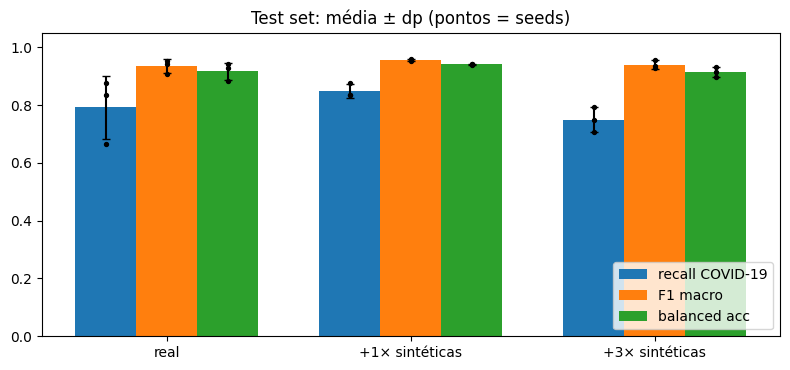

In [16]:
cols = ["rec_covid", "rec_pneumonia", "rec_normal", "f1_macro", "bal_acc", "auc_covid", "acc"]
summary = runs.groupby("arm", sort=False)[cols].agg(["mean", "std"])
fmt = pd.DataFrame({c: [f"{m:.3f} ± {s:.3f}" for m, s in zip(summary[c]["mean"], summary[c]["std"])] for c in cols},
                   index=summary.index)
print(f"Test set — média ± dp em {len(SEEDS)} seeds\n"); print(fmt.to_string())
RESULTS["experimento_por_seed"] = runs.to_dict(orient="records")

fig, ax = plt.subplots(figsize=(8, 3.8))
xpos = np.arange(len(ARMS)); wdt = 0.25
for k, (c, lab) in enumerate([("rec_covid", "recall COVID-19"), ("f1_macro", "F1 macro"), ("bal_acc", "balanced acc")]):
    ax.bar(xpos + (k - 1) * wdt, summary[c]["mean"], wdt, yerr=summary[c]["std"], capsize=3, label=lab)
    for s in SEEDS:
        v = runs[runs.seed == s].set_index("arm").loc[list(ARMS), c].values
        ax.scatter(xpos + (k - 1) * wdt, v, color="k", s=8, zorder=3)
ax.set_xticks(xpos, list(ARMS)); ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
ax.set_title("Test set: média ± dp (pontos = seeds)")
plt.tight_layout(); plt.savefig(FIG_DIR / "experimento_barras.png", dpi=120); plt.show()

                recall_covid            IC95  delta_vs_real       IC95_delta  P_delta_gt_0  f1_macro
arm                                                                                                 
real                   0.833  [0.667, 0.963]          0.000   [0.000, 0.000]         0.000     0.950
+1× sintéticas         0.875  [0.722, 1.000]          0.041  [-0.100, 0.185]         0.602     0.970
+3× sintéticas         0.750  [0.565, 0.920]         -0.081  [-0.259, 0.074]         0.101     0.942


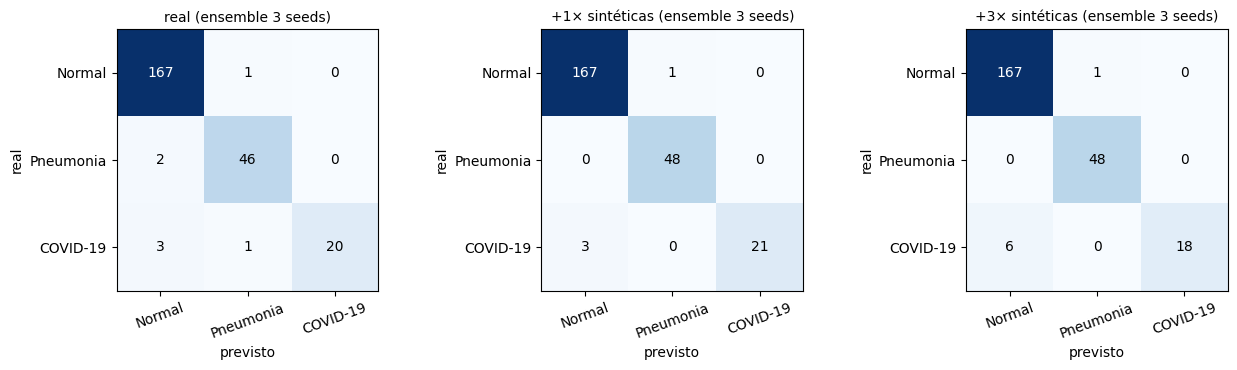

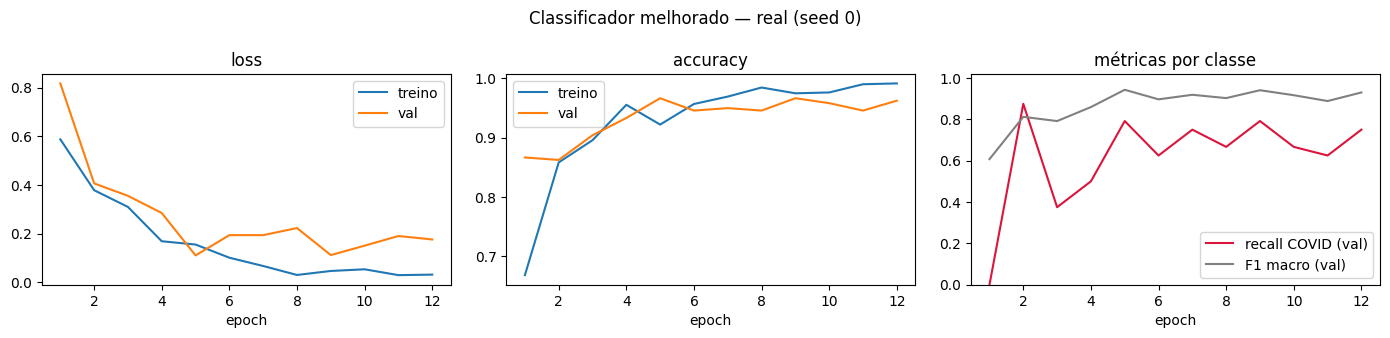

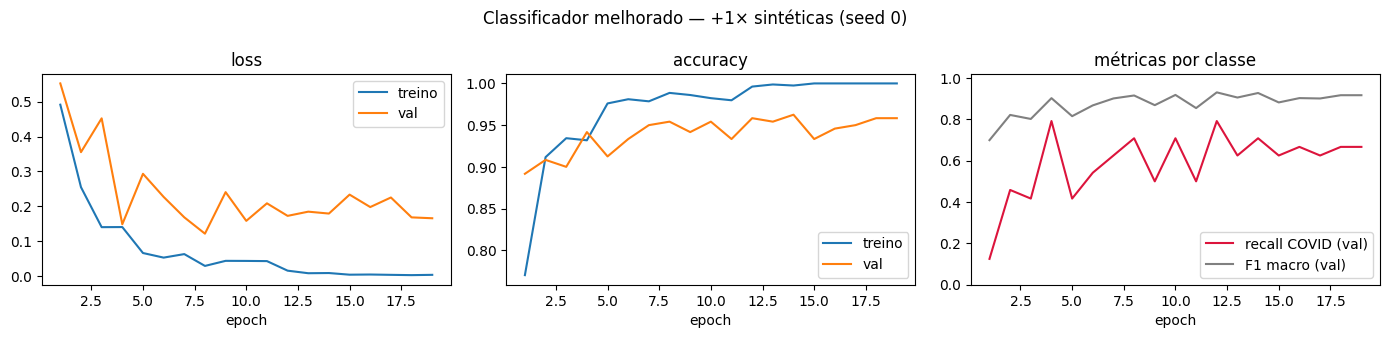

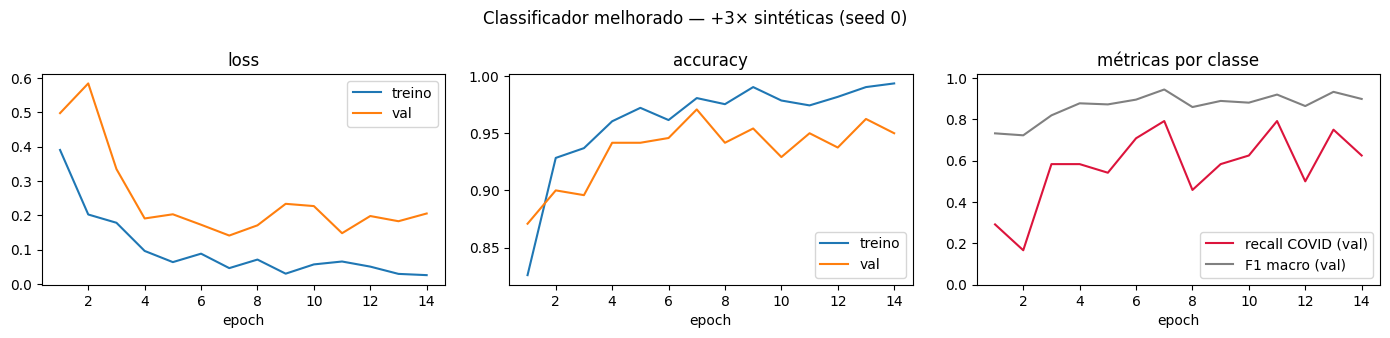

In [17]:
# Ensemble das 3 seeds por braço + IC 95% por bootstrap (reamostrando o test set) + diferença pareada vs. "real"
B = 2000
rng_b = np.random.default_rng(SEED)
boot_idx = rng_b.integers(0, len(te), (B, len(te)))
ens = {arm: np.mean([test_probs[arm, s] for s in SEEDS], 0) for arm in ARMS}


def rec_covid_vec(pred, yy):  # recall COVID para cada reamostragem (linhas de boot_idx)
    pos = yy == COVID
    return ((pred == COVID) & pos).sum(1) / np.maximum(pos.sum(1), 1)

yb = y[te][boot_idx]
ci_rows = []
base_boot = rec_covid_vec(ens["real"].argmax(1)[boot_idx], yb)
for arm in ARMS:
    pred = ens[arm].argmax(1)
    r = rec_covid_vec(pred[boot_idx], yb); d = r - base_boot
    ci_rows.append(dict(arm=arm, recall_covid=recall_score(y[te] == COVID, pred == COVID),
                        IC95=f"[{np.percentile(r, 2.5):.3f}, {np.percentile(r, 97.5):.3f}]",
                        delta_vs_real=np.mean(d), IC95_delta=f"[{np.percentile(d, 2.5):.3f}, {np.percentile(d, 97.5):.3f}]",
                        P_delta_gt_0=(d > 0).mean(), f1_macro=f1_score(y[te], pred, average="macro")))
ci_tab = pd.DataFrame(ci_rows).set_index("arm")
print(ci_tab.round(3).to_string())
RESULTS["experimento_ensemble"] = ci_tab.reset_index().to_dict(orient="records")

fig, axes = plt.subplots(1, len(ARMS), figsize=(4.3 * len(ARMS), 3.8))
for a, arm in zip(axes, ARMS):
    plot_cm(a, y[te], ens[arm].argmax(1), f"{arm} (ensemble 3 seeds)")
plt.tight_layout(); plt.savefig(FIG_DIR / "experimento_confusao.png", dpi=120); plt.show()

for arm in ARMS:
    plot_curves(hists[arm, 0], f"Classificador melhorado — {arm} (seed 0)",
                f"curvas_{arm.replace('+', 'mais').replace('×', 'x').replace(' ', '_').replace('é', 'e')}.png")

### 6.1 Checagem de atalho: o modelo aprendeu "imagem suave = COVID"?

As sintéticas são 64×64 ampliadas — mais suaves que as reais. Se o classificador usar a suavidade como pista,
imagens **reais Normal/Pneumonia degradadas** (224 → 64 → 224) passariam a ser classificadas como COVID. Meço a
fração de negativos do test prevista como COVID, antes e depois da degradação, em cada braço.

In [18]:
def degrade(Xu8):
    t = torch.from_numpy(Xu8).float().unsqueeze(1) / 255
    t = F.interpolate(F.interpolate(t, size=GAN_RES, mode="area"), size=IMG, mode="bilinear", align_corners=False)
    return (t.clamp(0, 1) * 255).round().byte().squeeze(1).numpy()

neg = te[y[te] != COVID]
dl_neg, dl_neg_deg = make_loader(X[neg], y[neg]), make_loader(degrade(X[neg]), y[neg])
m_eval = make_model(pretrained=False)
sc_rows = []
for arm in ARMS:
    for s in SEEDS:
        m_eval.load_state_dict(states[arm, s])
        p0, _ = predict(m_eval, dl_neg); p1, _ = predict(m_eval, dl_neg_deg)
        sc_rows.append(dict(arm=arm, seed=s, fp_covid_original=(p0.argmax(1) == COVID).mean(),
                            fp_covid_degradada=(p1.argmax(1) == COVID).mean()))
shortcut = pd.DataFrame(sc_rows).groupby("arm", sort=False)[["fp_covid_original", "fp_covid_degradada"]].mean()
print("Fração de negativos (Normal+Pneumonia) do test previstos como COVID-19:\n"); print(shortcut.round(3).to_string())
RESULTS["checagem_atalho"] = shortcut.reset_index().to_dict(orient="records")

Fração de negativos (Normal+Pneumonia) do test previstos como COVID-19:

                fp_covid_original  fp_covid_degradada
arm                                                  
real                        0.005               0.102
+1× sintéticas              0.002               0.023
+3× sintéticas              0.002               0.019


### 6.2 Grad-CAM: onde o modelo olha?

Grad-CAM (Selvaraju et al., 2017) na última camada convolucional (`layer4`) para a classe COVID-19, em casos
COVID do test. Ativação dentro dos campos pulmonares é esperada; ativação em bordas, texto ou marcadores indica
atalho de fonte.

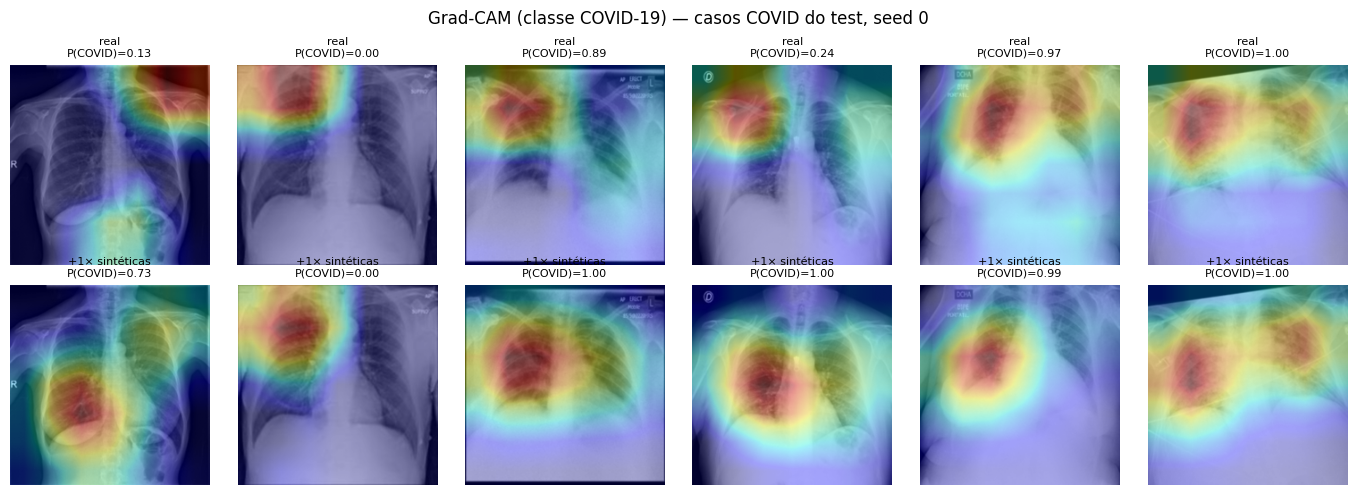

In [19]:
def gradcam(model, x, cls=COVID):
    store = {}

    def fwd_hook(_, __, out):
        store["a"] = out
        out.register_hook(lambda g: store.__setitem__("g", g))
    h = model.layer4.register_forward_hook(fwd_hook)
    model.eval(); model.zero_grad()
    model(x)[:, cls].sum().backward(); h.remove()
    w = store["g"].mean(dim=[2, 3], keepdim=True)
    cam = F.relu((w * store["a"]).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
    return (cam / (cam.amax(dim=[1, 2], keepdim=True) + 1e-8)).detach().cpu().numpy()

pos = te[y[te] == COVID][:6]
xb = torch.stack([XRayDS(X[pos], y[pos])[k][0] for k in range(len(pos))]).to(device)
arms_cam = ["real", list(ARMS)[1]]
fig, axes = plt.subplots(len(arms_cam), len(pos), figsize=(2.3 * len(pos), 2.5 * len(arms_cam)))
for r, arm in enumerate(arms_cam):
    m_eval.load_state_dict(states[arm, 0])
    cams = gradcam(m_eval, xb)
    with torch.no_grad():
        pc = m_eval(xb).softmax(1)[:, COVID].cpu().numpy()
    for k in range(len(pos)):
        axes[r, k].imshow(X[pos][k], cmap="gray"); axes[r, k].imshow(cams[k], cmap="jet", alpha=0.35)
        axes[r, k].set_title(f"{arm}\nP(COVID)={pc[k]:.2f}", fontsize=8); axes[r, k].axis("off")
plt.suptitle("Grad-CAM (classe COVID-19) — casos COVID do test, seed 0"); plt.tight_layout()
plt.savefig(FIG_DIR / "gradcam.png", dpi=120); plt.show()

### 6.3 Ponto de operação para triagem

Em triagem, o limiar é uma **decisão clínica**, não o argmax. Escolho, **na validação**, o maior limiar
`t` em P(COVID) que garante recall ≥ 0,95 e aplico no test (regra: COVID se P(COVID) ≥ t; senão, argmax entre
Normal/Pneumonia). Reporto sensibilidade, especificidade e VPP do COVID-vs-resto.

In [20]:
TARGET_RECALL = 0.95
op_rows = []
for arm in ARMS:
    pv = np.mean([val_probs[arm, s] for s in SEEDS], 0); pt = ens[arm]
    pos_v = np.sort(pv[y[va] == COVID, COVID])[::-1]
    t = pos_v[math.ceil(TARGET_RECALL * len(pos_v)) - 1]
    yt, pred = y[te] == COVID, pt[:, COVID] >= t
    tp, fn = (pred & yt).sum(), (~pred & yt).sum(); fp, tn = (pred & ~yt).sum(), (~pred & ~yt).sum()
    op_rows.append(dict(arm=arm, limiar=t, sensibilidade=tp / (tp + fn), especificidade=tn / (tn + fp),
                        VPP=tp / max(tp + fp, 1), FN=int(fn), FP=int(fp)))
op_tab = pd.DataFrame(op_rows).set_index("arm")
print(f"Limiar escolhido na validação para recall ≥ {TARGET_RECALL}; métricas no test:\n"); print(op_tab.round(3).to_string())
RESULTS["ponto_operacao"] = op_tab.reset_index().to_dict(orient="records")

Limiar escolhido na validação para recall ≥ 0.95; métricas no test:

                limiar  sensibilidade  especificidade    VPP  FN  FP
arm                                                                 
real             0.094          0.958           0.949  0.676   1  11
+1× sintéticas   0.003          0.958           0.866  0.442   1  29
+3× sintéticas   0.002          0.958           0.847  0.411   1  33


**Análise.**

**1. Corrigir o protocolo é o maior ganho.** O mesmo tipo de ResNet-18, com pré-treino ImageNet, class weights,
augmentation e early stopping pelo F1 macro, sobe a recall COVID de **0,30** (reprodução, §3) para **0,79 ± 0,11**
só com dados reais (0,83 no ensemble). As partições não são idênticas (validação do baseline vs. test), mas a
diferença é grande demais para ser ruído de split.

**2. Com vs. sem sintéticas.**

| Braço | Recall COVID (3 seeds) | Ensemble | Δ vs. real (IC 95%) | F1 macro |
|---|---|---|---|---|
| real | 0,792 ± 0,110 | 20/24 = 0,833 | — | 0,934 ± 0,024 |
| +1× sintéticas | **0,847 ± 0,024** | 21/24 = 0,875 | +0,041 [−0,100; +0,185] | **0,956 ± 0,003** |
| +3× sintéticas | 0,750 ± 0,042 | 18/24 = 0,750 | −0,081 [−0,259; +0,074] | 0,940 ± 0,015 |

- **+1×** melhora a média e, principalmente, **reduz a variância entre seeds** (dp 0,110 → 0,024). O IC 95% da
  diferença inclui zero (P(Δ>0) = 0,60): **com 24 positivos no test, o ganho não é distinguível do ruído**. A melhora
  consistente está no F1 macro e na Pneumonia (0 erros vs. 2).
- **+3× piora.** Com 216 sintéticas para 72 reais, **75% da classe COVID passa a ser sintética**: o modelo aprende a
  aparência das sintéticas (64 px, granuladas), que difere da COVID real, e manda 6 casos COVID reais para Normal.
  Além disso, os class weights caem para COVID (288 amostras), reduzindo o peso dos casos reais. Há um **ponto ótimo
  de proporção sintético/real**, e ele é baixo.
- Os erros restantes são quase todos **COVID → Normal** — o pior erro clinicamente (paciente liberado).

**3. Checagem de atalho.** Negativos degradados (224 → 64 → 224) previstos como COVID: real **10,2%**, +1× **2,3%**,
+3× **1,9%**. Não há atalho "imagem suave = COVID" nos braços com sintéticas (as sintéticas são granuladas, não
suaves). O resultado do braço real é o mais interessante: degradar a imagem a empurra para COVID — hipótese
compatível com o **viés de fonte** da base (imagens COVID de compilações com qualidade/resolução menor que as Normal).

**4. Grad-CAM.** No braço real, os dois casos com P(COVID) baixa (0,13 e 0,24) têm ativação no **canto superior da
imagem / abdômen**, fora dos pulmões. No +1×, os mesmos casos sobem para 0,73 e 1,00 com ativação **nos campos
pulmonares**. Com 6 exemplos é qualitativo, mas é o comportamento desejado.

**5. Ponto de operação (o resultado que decide).** Fixando o limiar na validação para recall ≥ 0,95, os três braços
chegam a **sensibilidade 0,958 no test (23/24, 1 FN)**, mas o custo em falsos positivos é muito diferente:
especificidade **0,949 (11 FP)** no braço real vs. 0,866 (29 FP) e 0,847 (33 FP) com sintéticas. As sintéticas
deixam o modelo mais confiante nos casos fáceis e pior em ordenar os casos limítrofes — foi preciso limiar 0,003
para alcançar a recall-alvo. **No regime de triagem, o modelo só com dados reais é o melhor.**

**Conclusão do experimento:** com esta cGAN 64×64, a augmentation sintética **não produziu ganho estatisticamente
defensável na recall COVID**. Em proporção 1:1 ela estabilizou o treino (menos variância, melhor F1 macro); em 3:1
atrapalhou; e no ponto de operação clínico piorou a especificidade. O ganho real veio de corrigir o protocolo.

## 7. Plano de melhoria integrado

| Eixo | Problema(s) do §2 | Ação | Evidência neste notebook |
|---|---|---|---|
| **Dados e split** | 3, 8 | Split estratificado **por paciente** (evita o mesmo paciente em treino e teste), test isolado, e **validação externa** em hospital/equipamento não visto no treino. Coletar mais casos COVID reais (prioridade sobre qualquer síntese) | §1, §2 (variância do split) |
| **Modelo** | 4, 6 | Backbone **pré-treinado** (ImageNet; idealmente pré-treino em raio-X, ex. CheXpert/MIMIC-CXR), fine-tuning com AdamW + cosine, early stopping pelo F1 macro de validação, checkpoint do melhor epoch | §3 vs. §6 |
| **Desbalanceamento** | 2 | Class weights (ou focal loss / sampler balanceado); augmentation sintética **como complemento**, nunca substituto de dado real | §6 |
| **Augmentation clássica** | 5 | Rotação ±10°, translação/escala leves, brilho/contraste (exposição), blur; **sem** flip horizontal (lateralidade cardíaca) e sem distorções que alterem a anatomia | §3 |
| **Augmentation sintética** | 2, 5 | cGAN com spectral norm + DiffAugment (estável com poucos dados), treinada só no treino; gates de qualidade: KID, diversidade, checagem de memorização (vizinho mais próximo), **leitura cega por radiologista** das sintéticas; evoluir para 128–256 px ou modelo de difusão | §4–§5 |
| **Métrica** | 1 | Métrica primária: **recall (sensibilidade) COVID-19 com IC 95%**; secundárias: especificidade, VPP, F1 macro, balanced accuracy, AUC; sempre matriz de confusão e por classe; comparação com a baseline trivial | §6 |
| **Ponto de operação** | 7 | Limiar escolhido na validação para a sensibilidade-alvo do protocolo clínico, congelado antes do test | §6.3 |
| **Interpretabilidade e viés** | 8 | Grad-CAM por amostra, testes de atalho (degradação, máscara pulmonar, troca de fonte), análise por subgrupo (AP vs. PA, sexo, idade, equipamento) | §6.1, §6.2 |

**Critério de adoção clínica (proposto).** O sistema só sai de pesquisa se, em **test externo** (outro hospital):
1. **Sensibilidade COVID-19 ≥ 0,95 com limite inferior do IC 95% ≥ 0,90** no limiar congelado;
2. **Especificidade ≥ 0,80** (carga aceitável de RT-PCR confirmatório), sem queda > 5 p.p. em nenhum subgrupo;
3. Sem ganho atribuível a atalho (Grad-CAM e testes de atalho aprovados por radiologista);
4. Desempenho **não inferior ao radiologista** em estudo retrospectivo pareado;
5. Implantação inicial em **modo silencioso** (roda em paralelo, sem influenciar a conduta) com monitoramento de
   drift e auditoria de falsos negativos; uso final como **apoio à triagem** — nunca diagnóstico autônomo.

**Onde o melhor modelo deste notebook está (braço real, limiar para recall ≥ 0,95):**

| Critério | Resultado | Status |
|---|---|---|
| 1. Sensibilidade ≥ 0,95 com IC inferior ≥ 0,90 | 0,958 (23/24), IC 95% de Wilson ≈ [0,80; 0,99] | ❌ ponto ok, IC largo demais — precisa de ≥ ~100 positivos no test |
| 2. Especificidade ≥ 0,80 | 0,949 (11 FP em 216 negativos) | ✅ neste test (sem subgrupos) |
| 3. Sem atalho | Grad-CAM misto; degradação empurra para COVID (10%) | ❌ indício de viés de fonte |
| 4. Não inferior ao radiologista | não avaliado | — |
| 5. Modo silencioso / validação externa | não avaliado | — |

**Veredito:** o sistema corrigido é **muito melhor que o original** (recall COVID 0,30 → ~0,8 no argmax e 0,96 no
limiar de triagem), mas **ainda não atende o critério de adoção clínica**. O próximo passo não é outro modelo, e sim
**mais dados COVID reais** (para estreitar o IC), **validação externa** e **mitigação do viés de fonte**. A
augmentation sintética fica como experimento secundário: GAN mitigada treinada por mais tempo, em resolução maior,
com proporção sintético/real ≤ 1:1 e aprovação das sintéticas por radiologista.

## 8. Conclusões e limitações

- **Diagnóstico confirmado na prática.** O protocolo do grupo anterior reproduzido nesta base dá 90% de accuracy e
  **recall COVID de 0,30** — "ignora casos positivos" exatamente como relatou o time clínico, e a accuracy esconde
  isso. O classificador trivial "sempre Normal" (70%) já supera os 61% reportados.
- **A maior melhoria vem do básico:** pré-treino, class weights, augmentation plausível, split estratificado com test
  isolado, early stopping pela métrica certa → recall COVID ~0,8 (argmax) e 0,96 com limiar de triagem.
- **GAN:** a vanilla diverge por overfitting do discriminador (D_gap 0,82); spectral norm e DiffAugment eliminam a
  divergência (D_gap ≈ 0), ao custo de convergência mais lenta no mesmo orçamento (KID pior em 5 mil iterações).
- **Augmentation sintética:** 1:1 reduziu a variância e melhorou o F1 macro, mas o ganho de recall COVID não é
  significativo com 24 positivos; 3:1 piorou; no ponto de operação clínico, sintéticas pioraram a especificidade.
  **Dado sintético não substitui dado real** — e precisa de gates de qualidade antes de entrar no treino.

**Limitações:** test com apenas 24 positivos (IC largos); GAN em 64×64 não reproduz padrões finos (vidro fosco);
dataset público com viés de fonte; sem informação de paciente para split por paciente; sem validação externa.

**Referências**
- Nour, M. & Tariq, U. (2023). *Scientific Reports*. https://www.nature.com/articles/s41598-023-37743-4
- Chowdhury, M. E. H. et al. (2020). Can AI help in screening viral and COVID-19 pneumonia? *IEEE Access*. · Rahman, T. et al. (2021). *Computers in Biology and Medicine* — COVID-19 Radiography Database.
- DeGrave, A. J., Janizek, J. D. & Lee, S.-I. (2021). AI for radiographic COVID-19 detection selects shortcuts over signal. *Nature Machine Intelligence*.
- Roberts, M. et al. (2021). Common pitfalls and recommendations for using machine learning to detect and prognosticate for COVID-19 using chest radiographs and CT scans. *Nature Machine Intelligence*.
- Radford, A., Metz, L. & Chintala, S. (2016). DCGAN. *ICLR*. · Mirza, M. & Osindero, S. (2014). Conditional GAN.
- Miyato, T. et al. (2018). Spectral Normalization for GANs. *ICLR*. · Heusel, M. et al. (2017). TTUR / FID. *NeurIPS*.
- Zhao, S. et al. (2020). Differentiable Augmentation for Data-Efficient GAN Training. *NeurIPS*. · Karras, T. et al. (2020). ADA. *NeurIPS*.
- Bińkowski, M. et al. (2018). Demystifying MMD GANs (KID). *ICLR*. · Selvaraju, R. R. et al. (2017). Grad-CAM. *ICCV*.

## Uso de IA

Ferramentas de IA utilizadas para auxílio neste notebook

Todo o código foi executado e validado pelo autor; as análises e conclusões foram verificadas contra os resultados
reais obtidos.

## Medições e exportação

Imprime tempo total, VRAM e RAM (para a tabela de requisitos), salva `results.json` e compacta `figures/`.

In [21]:
import psutil
TIMES["total"] = time.time() - T_START
RESULTS["tempos_s"] = {k: round(v, 1) for k, v in TIMES.items()}
RESULTS["vram_pico_gb"] = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else None
RESULTS["ram_processo_gb"] = psutil.Process().memory_info().rss / 1e9
print(json.dumps({k: RESULTS[k] for k in ["tempos_s", "vram_pico_gb", "ram_processo_gb"]}, indent=2))

with open(FIG_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=2, ensure_ascii=False, default=float)
shutil.make_archive(str(ROOT / "figures"), "zip", FIG_DIR)
print("figuras + results.json em", ROOT / "figures.zip")
if IN_COLAB:
    from google.colab import files
    files.download(str(ROOT / "figures.zip"))

{
  "tempos_s": {
    "1_dataset": 26.5,
    "3_baseline": 45.1,
    "5_gan_treino": 1523.8,
    "5_gan_avaliacao": 17.9,
    "6_experimento": 534.2,
    "total": 2171.3
  },
  "vram_pico_gb": 4.895298048,
  "ram_processo_gb": 3.627008
}
figuras + results.json em /content/figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>